In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0092_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0322_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0304_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0242_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0041_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0288_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0036_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0272_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0171_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0074_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0235_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0184_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0243_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0013_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0136_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0227_0.png
/kaggle/input/chines-data-only/CXR_png/0/CHNCXR_0314_0.p

# STEP 1: Install libraries
# ===========================

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential,layers
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/chines-data-only/CXR_png',
    labels= "inferred",
    label_mode = 'binary',
    batch_size = 32,
    image_size = (256, 256),
    seed=42,
    shuffle=True,
    validation_split = 0.2,
    subset='training',
    color_mode = 'rgb'
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/chines-data-only/CXR_png',
    labels = 'inferred',
    label_mode = 'binary',
    batch_size = 32,
    shuffle = False,
    validation_split = 0.2,
    subset ='validation',
    color_mode = 'rgb',
    image_size = (256, 256),
    seed=42
)

Found 662 files belonging to 2 classes.
Using 530 files for training.
Found 662 files belonging to 2 classes.
Using 132 files for validation.


2025-10-30 07:47:20.927802: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
# for checking number of classes in my dataset folder
class_names = train_ds.class_names
print("Class names:", class_names)


Class names: ['0', '1']


In [6]:
 # Normalization

def process(image, label):
    image = tf.cast(image/255, tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [7]:
data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

# Apply only on training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


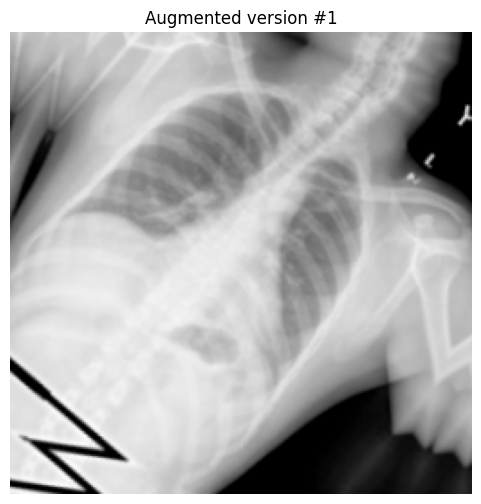

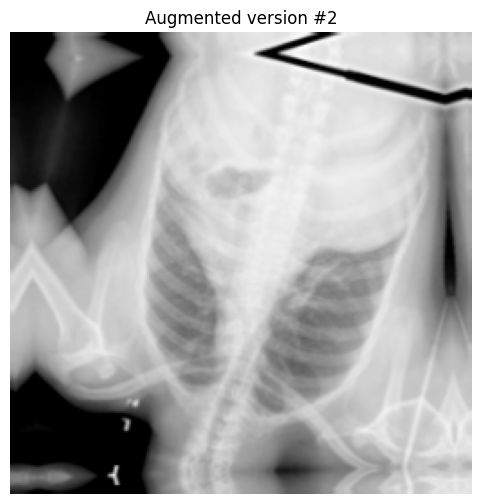

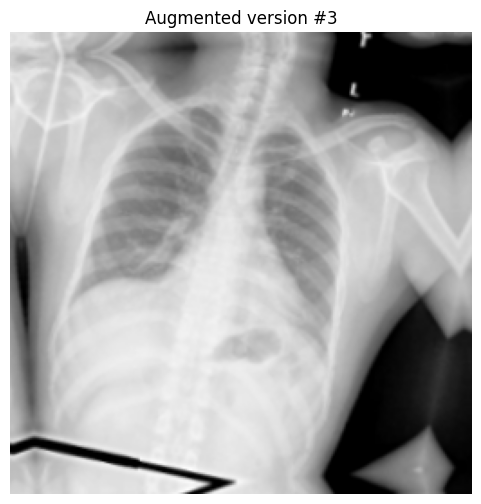

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Take one batch from training dataset
for images, labels in train_ds.take(1):
    # Apply augmentation multiple times
    for i in range(3):
        augmented_images = data_augmentation(images, training=True)
        
        # Take one image from augmented batch
        img = augmented_images[0]
        
        # Convert grayscale → RGB if needed
        if img.shape[-1] == 1:
            img = tf.image.grayscale_to_rgb(img)
        
        # Convert tensor to image for plotting
        img = tf.keras.utils.array_to_img(img)
        
        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.title(f"Augmented version #{i+1}")
        plt.axis("off")
        plt.show()


In [8]:
# Create CNN Archetecture

model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), padding="valid", strides=2))
# model.add(BatchNormalization())


model.add(Conv2D(64, kernel_size=(3,3), padding="valid", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), padding="valid", strides=2))
# model.add(BatchNormalization())


model.add(Conv2D(128, kernel_size=(3,3), padding="valid", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), padding="valid", strides=2))
# model.add(BatchNormalization())


model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(32, activation="relu"))
# model.add(Droupout(0.3))
model.add(Dense(1, activation="sigmoid"))

In [9]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,345 (56.65 MB)

 Trainable params: 14,849,345 (56.65 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [13]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history = model.fit(train_ds, validation_data=validation_ds, epochs=50, callbacks=[early_stopping])

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 92s 5s/step - accuracy: 0.4575 - loss: 1.0007 - val_accuracy: 0.9848 - val_loss: 0.6852
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 126s 4s/step - accuracy: 0.5115 - loss: 0.6934 - val_accuracy: 0.9924 - val_loss: 0.6878
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.5292 - loss: 0.6903 - val_accuracy: 0.0076 - val_loss: 0.7324
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.6211 - loss: 0.6565 - val_accuracy: 0.8030 - val_loss: 0.6812
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.5567 - loss: 0.6894 - val_accuracy: 0.9848 - val_loss: 0.6633
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.5551 - loss: 0.6849 - val_accuracy: 0.1667 - val_loss: 0.7749
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.6574 - loss: 0.6389 - val_accuracy: 0.5000 - val_loss: 0.7579
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.7210 - loss: 0.6187 - val_accuracy: 0.7879 - val_loss

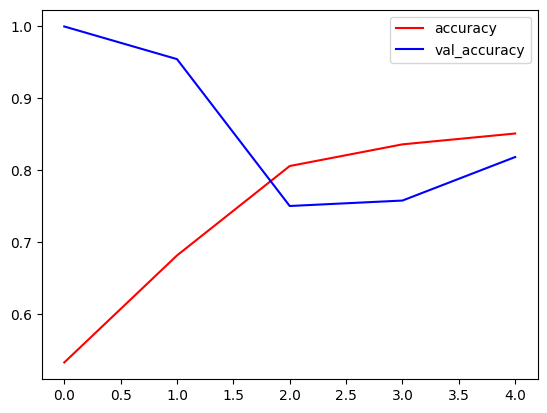

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color="red", label="accuracy")
plt.plot(history.history['val_accuracy'], color="blue", label="val_accuracy")
plt.legend()
plt.show()

In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [13]:
image_path = "/kaggle/input/cmbine-chines-and-montogmery/combine_chines_and_montgomerCXRSet/TB/CHNCXR_0327_1.png"

image = keras.utils.load_img(image_path,target_size=(256,256))
image_array = keras.utils.img_to_array(image)
image_array = image_array/255.0
image_array = np.expand_dims(image_array, axis=0)

In [14]:
prediction = model.predict(image_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


In [15]:
if prediction[0][0] > 0.5:
    print("TB")
else:
    print("Normal")

print("Raw probability: ", prediction[0][0])

TB
Raw probability:  0.95661604


In [16]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

def new_prediction(image_path):
    img_path = image_path
    image = keras.utils.load_img(img_path, target_size=(256,256))
    image_array = keras.utils.img_to_array(image)
    image_array = image_array/255.0
    image_array = np.expand_dims(image_array, axis=0)
    prediction = model.predict(image_array)

    if prediction[0][0] > 0.5:
        print("TB Detected")
    else:
        print("Normal")

    print("raw probability: ", prediction[0][0]*100)
    

In [17]:
new_prediction("/kaggle/input/cmbine-chines-and-montogmery/combine_chines_and_montgomerCXRSet/Normal/CHNCXR_0067_0.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Normal
raw probability:  12.503905594348907
